# VLISM structure functions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, signal
from scipy.stats import linregress


from fbm import FBM

# Add .. to the path
import sys

sys.path.append("..")
import src.sf_funcs as sf_funcs

plt.rc("font", family="Arial")

In [ ]:
v1_raw = pd.read_pickle("../data/interim/voyager/voyager1_lism_cleaned.pkl")
v1_raw.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7461001 entries, 2012-08-25 00:00:00 to 2023-12-31 00:00:00
Freq: 48s
Data columns (total 4 columns):
 #   Column  Dtype  
---  ------  -----  
 0   F1      float32
 1   BR      float32
 2   BT      float32
 3   BN      float32
dtypes: float32(4)
memory usage: 170.8 MB


In [3]:
v1_res = v1_raw.resample("1d").mean()
v1_res.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4146 entries, 2012-08-25 to 2023-12-31
Freq: D
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F1      3969 non-null   float32
 1   BR      3969 non-null   float32
 2   BT      3969 non-null   float32
 3   BN      3969 non-null   float32
dtypes: float32(4)
memory usage: 97.2 KB


In [4]:
v2_raw = pd.read_pickle("../data/interim/voyager/voyager2_lism.pkl")
v2_res = v2_raw.resample("1d").mean()
v2_res.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1518 entries, 2018-11-05 to 2022-12-31
Freq: D
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F1      1438 non-null   float32
 1   BR      1438 non-null   float32
 2   BT      1438 non-null   float32
 3   BN      1438 non-null   float32
dtypes: float32(4)
memory usage: 35.6 KB


## Low-res SFs (daily)

In [5]:
sf_v1 = sf_funcs.compute_sf(
    v1_res[["BR", "BT", "BN"]], np.arange(1, len(v1_res)), [2], False, False, None
)

sf_v2 = sf_funcs.compute_sf(
    v2_res[["BR", "BT", "BN"]], np.arange(1, len(v2_res)), [2], False, False, None
)

### Investigating noise

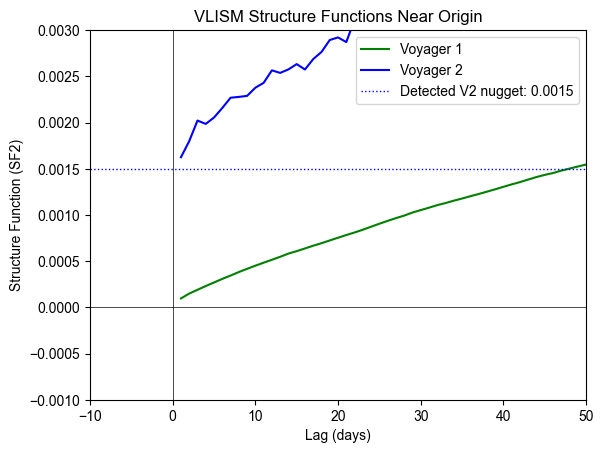

In [71]:
plt.plot(
    sf_v1["lag"],
    sf_v1["sf_2"],
    label="Voyager 1",
    c="green"
)
plt.plot(
    sf_v2["lag"],
    sf_v2["sf_2"],
    label="Voyager 2",
    c="blue"
)
# Set axis limits
plt.xlim(-10, 50)
plt.ylim(-0.001, 0.003)
# Add horizontal line at y=0
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black",linewidth=0.5)

nugget_v2_lr = 0.0015

plt.axhline(
    nugget_v2_lr,
    color="blue",
    linestyle=":",
    linewidth=1,
    label=f"Detected V2 nugget: {nugget_v2_lr}",
)


plt.legend()
plt.xlabel("Lag (days)")
plt.ylabel("Structure Function (SF2)")
plt.title("VLISM Structure Functions Near Origin");

In [ ]:
sigma_err_v2_lr = np.sqrt(nugget_v2_lr / 2)
print("This gives a standard deviation of the V2 LR error of", round(sigma_err_v2_lr,3))

This gives a standard deviation of the V2 LR error of 0.027


## High-res SFs (48s)

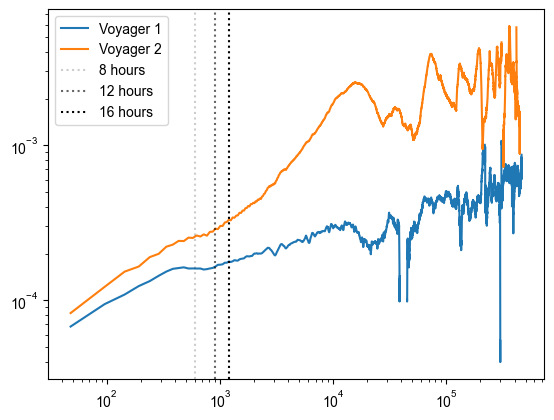

In [ ]:
v1_raw_sub = v1_raw[:15000]
v2_raw_sub = v2_raw[:15000]

sf_v1_hr = sf_funcs.compute_sf(
    v1_raw_sub[["BR", "BT", "BN"]],
    np.arange(1, len(v1_raw_sub)),
    [2],
    False,
    False,
    None,
)

sf_v2_hr = sf_funcs.compute_sf(
    v2_raw_sub[["BR", "BT", "BN"]],
    np.arange(1, len(v2_raw_sub)),
    [2],
    False,
    False,
    None,
)


### Investigating noise

Text(0.5, 1.0, 'VLISM Structure Functions Near Origin')

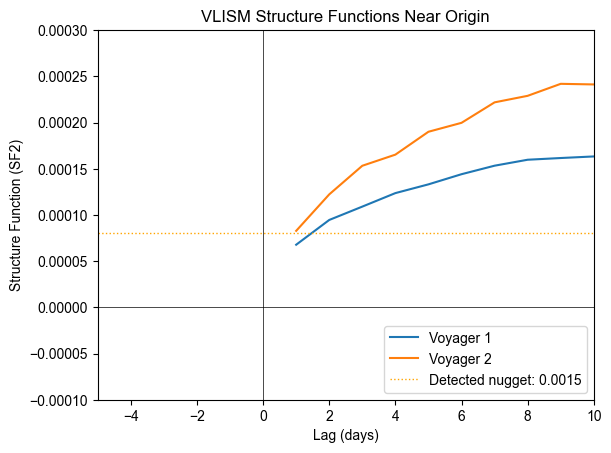

In [ ]:
plt.plot(
    sf_v1_hr["lag"],
    sf_v1_hr["sf_2"],
    label="Voyager 1",
)
plt.plot(
    sf_v2_hr["lag"],
    sf_v2_hr["sf_2"],
    label="Voyager 2",
)

# Set axis limits
plt.xlim(-5, 10)
plt.ylim(-0.0001, 0.0003)
# Add horizontal line at y=8

plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)


nugget_hr = 0.00008


plt.axhline(
    nugget_hr,
    color="orange",
    linestyle=":",
    linewidth=1,
    label=f"Detected nugget: {nugget_hr}}",
)


plt.legend()
plt.xlabel("Lag (days)")
plt.ylabel("Structure Function (SF2)")
plt.title("VLISM Structure Functions Near Origin")

In [78]:
sigma_err_hr = np.sqrt(nugget_hr / 2)
print(
    "This gives a standard deviation of the V1 and V2 HR error of",
    round(sigma_err_hr, 3),
)

This gives a standard deviation of the V1 and V2 HR error of 0.006


## Combined plot

Text(3600.0, 2e-05, '$d_i$')

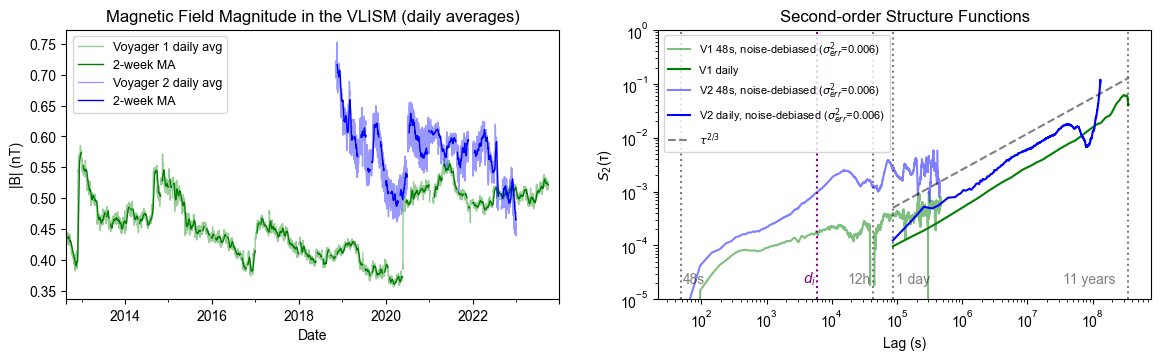

In [79]:
fig, ax = plt.subplots(1, 2, figsize=(14, 3.5))
v1_res["F1"].plot(ax=ax[0], label="Voyager 1 daily avg", c="green", lw=1, alpha=0.4)
# Add moving average
v1_res["F1"].rolling(window=14).mean().plot(ax=ax[0], label="2-week MA", c="green", lw=1)
v2_res["F1"].plot(ax=ax[0], label="Voyager 2 daily avg", c="blue", lw=1, alpha=0.4)
# Add moving average
v2_res["F1"].rolling(window=14).mean().plot(ax=ax[0], label="2-week MA", c="blue", lw=1)
ax[0].legend(fontsize=9)
ax[0].set_ylabel("|B| (nT)")
ax[0].set_xlabel("Date")

ax[1].plot(
    sf_v1_hr.lag * 48,
    sf_v1_hr.sf_2 - nugget_hr,
    color="green",
    alpha=0.5,
    label=f"V1 48s, noise-debiased ($\sigma^2_{{err}}$={sigma_err_hr:.3f})",
)
ax[1].plot(sf_v1.lag * 86400, sf_v1.sf_2, color="green", label="V1 daily")

ax[1].plot(
    sf_v2_hr.lag * 48,
    sf_v2_hr.sf_2 - nugget_hr,
    color="blue",
    alpha=0.5,
    label=f"V2 48s, noise-debiased ($\sigma^2_{{err}}$={sigma_err_hr:.3f})",
)

ax[1].plot(
    sf_v2.lag * 86400,
    sf_v2.sf_2 - nugget_v2_lr,
    color="blue",
    label=f"V2 daily, noise-debiased ($\sigma^2_{{err}}$={sigma_err_v2_lr:.3f})",
)


# Plot 2/3 power law
ax[1].plot(
    sf_v1.lag * 86400,
    0.0005 * np.power(sf_v1.lag, 2 / 3),
    label="$\\tau^{2/3}$",
    color="black",
    linestyle="--",
    alpha=0.5,
)

ax[1].legend(loc="upper left", fontsize=8)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
# ax[1].set_xlim(5e1, 4e8)
ax[1].set_ylim(1e-5, 1e0)
ax[1].set_xlabel("Lag (s)")
ax[1].set_ylabel("$S_2$(τ)")
ax[0].set_title("Magnetic Field Magnitude in the VLISM (daily averages)")
ax[1].set_title(f"Second-order Structure Functions")

# Add vertical line at 1 day lag, with annotation
ax[1].axvline(86400, color="black", linestyle=":", alpha=0.5)
ax[1].annotate(
    "1 day",
    xy=(86400*1.1, 2e-5),
    fontsize=10,
    alpha=0.5,
)
# Add vertical line at 11 years lag, with annotation
ax[1].axvline(11 * 365 * 86400, color="black", linestyle=":", alpha=0.5)
ax[1].annotate(
    "11 years",
    xy=(11 * 365 * 86400*0.1, 2e-5),
    fontsize=10,
    alpha=0.5,
)

ax[1].axvline(48, color="black", linestyle=":", alpha=0.5)
ax[1].annotate(
    "48s",
    xy=(48 * 1.1, 2e-5),
    fontsize=10,
    alpha=0.5,
)

# Add vertical line at 12 hours lag, with annotation
ax[1].axvline(12 * 3600, color="black", linestyle=":", alpha=0.5)
ax[1].annotate(
    "12h",
    xy=(12 * 3600 * 0.4, 2e-5),
    fontsize=10,
    alpha=0.5,
)

ax[1].axvline(6e3, color="purple", linestyle=":")
ax[1].annotate(
    "$d_i$",
    xy=(0.6*6e3, 2e-5),
    fontsize=10,
    c="purple"
)

Daily averages of V1 LISM are very K41 monofractal! Certainly suggests not yet at outer scale...

---

Potentially relevant? 

- [Statistical inference of random field auto-correlation structure from multiple sets of incomplete and sparse measurements using Bayesian compressive sampling-based bootstrapping](https://www.sciencedirect.com/science/article/pii/S0888327019300652#s0065)
- [Interpolation uncertainty of atmospheric temperature profiles](https://amt.copernicus.org/articles/13/6445/2020/amt-13-6445-2020.html)